<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-header">

## Tutorial \#6: Solving the CartPole™

</div>

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Now it is the time to wrap all that we have learned so far and use <b><i>Spark</i></b> to solve one of the most iconic problems in reinforcement learning: the CartPole™.

The [CartPole](https://gymnasium.farama.org/environments/classic_control/cart_pole/) is a simple control problem in which a pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. The pendulum is placed upright on the cart and the goal is to balance the pole by applying forces in the left and right direction on the cart.

In order to solve the network, we require a neuron model capable of not only processing spikes, but also capable of receiving a signal like a reward in order to modulate its synaptic plasticity dynamics. For this case we will use a simple ALIF neruon (Adaptive-Leaky-Integrate-and-Fire). We will also add a modulated versions of a classical plasticity protocol known as the "quadruplet rule", which we are going to populate with parameters from: [Plasticity Cards®](https://plasticity.vogelslab.org/), a collection of parameters for the quadruplet rule that tends to produce stable dynamics. We took the liberty to prepare this neuronal model in advance (which will later appear as <b>spark.ALIFModNeuron</b>) and pack it into a file!.

Considering the action space for the CartPole problem, the brain needs to be capable on picking two actions: "move left" or "move right" depending on the current state of the cart. The input to the problem are four bounded float values: position, velocity, pole angle and pole angular velocity. Given the very nature of these values (they are continuous values that may be represented by segments of a line), we can use a <b>spark.nn.interfaces.TopologicalLinearSpiker</b> to map these values to an spiking pattern along a line (akin to grid cells!). For the core of the network, an "A vs B" design pattern will naturally induce a choice of left or right. This pattern may be summarized as: each population tries to main a high level of activity and supress the activity of the other population if it "believes" that it needs to act. Finally, for the output of the network, we can simply take the activity of A and B and pick which ever is more active at the present moment. In order to accomplish this, we will once again use the <b>spark.nn.interfaces.ExponentialIntegrator</b> and pick the action associated with most active population.

Overall, the plan is:

1. Design a neuron model that may be modulated via rewards.
2. Assamble everything into a brain.
3. Train the model
4. Profit! 

For this tutorial we prepared two files: <b>alif_mod_neuron.scfg</b> and <b>ab_brain.scfg</b> for the neuron and the brain respectively. You can find these two files in the main repository under the directory <b>/tutorials</b>.

Let's start by looking at the neuron model.

</div>

In [1]:
import sys
sys.path.append('../')
import spark
# Imports
%gui qt
import jax
import spark
import numpy as np
import jax.numpy as jnp

NEURON_PATH = './alif_mod_neuron_raw.scfg'
BRAIN_PATH = './ab_brain_raw.scfg'

editor = spark.GraphEditor()

------ N2NDelaysConfig ------
seed
dtype
dt
max_delay
delays
------ UniformInitializerConfig ------
dtype
scale
min_value
max_value
------ UniformInitializerConfig ------
dtype
scale
min_value
max_value
units
------ LinearSynapsesConfig ------
seed
dtype
dt
units
kernel
------ SparseUniformInitializerConfig ------
dtype
scale
min_value
max_value
density
------ SparseUniformInitializerConfig ------
dtype
scale
min_value
max_value
density
------ LeakySomaConfig ------
seed
dtype
dt
potential_rest
potential_reset
potential_tau
resistance
threshold
------ HebbianRuleConfig ------
seed
dtype
dt
pre_tau
post_tau
eta
------ N2NDelaysConfig ------
seed
dtype
dt
max_delay
delays
------ UniformInitializerConfig ------
dtype
scale
min_value
max_value
------ UniformInitializerConfig ------
dtype
scale
min_value
max_value
units
------ TracedSynapsesConfig ------
seed
dtype
dt
units
kernel
------ SparseUniformInitializerConfig ------
dtype
scale
min_value
max_value
density
------ SparseUniformInitia

In [2]:
config_instance = spark.nn.NeuronConfig.from_file(NEURON_PATH)

<_io.TextIOWrapper name='alif_mod_neuron_raw.scfg' mode='r' encoding='utf-8'>
{'__config_delimiter__': '__', '__shared_config_delimiter__': '_s_', '__metadata__': {}, '__graph_editor_metadata__': {}, 'dtype': <class 'numpy.float16'>, 'scale': 1, 'min_value': None, 'max_value': None, '__class_ref__': 'UniformInitializer'}
------ UniformInitializerConfig ------
dtype
scale
min_value
max_value
------ N2NDelaysConfig ------
seed
dtype
dt
max_delay
delays
------ UniformInitializerConfig ------
dtype
scale
min_value
max_value
units
------ QuadrupletRuleConfig ------
seed
dtype
dt
pre_tau
post_tau
q_alpha
q_beta
q_gamma
q_delta
eta
max_clip
------ AdaptiveLeakySomaConfig ------
seed
dtype
dt
potential_rest
potential_reset
potential_tau
resistance
threshold
cooldown
threshold_tau
threshold_delta
{'__config_delimiter__': '__', '__shared_config_delimiter__': '_s_', '__metadata__': {}, '__graph_editor_metadata__': {}, 'dtype': <class 'numpy.float16'>, 'scale': 1, 'min_value': None, 'max_value': N

In [3]:
config_instance.inspect()

NeuronConfig
├── modules_specs: list[ModuleSpecs]
│   ├── delays: N2NDelaysConfig
│   │   ├── seed: int <- 3730662515
│   │   ├── dtype: DTypeLike <- <class 'numpy.float16'>
│   │   ├── dt: float <- 1.0
│   │   ├── max_delay: float <- 8.0
│   │   ├── delays: UniformInitializerConfig
│   │   │   ├── dtype: DTypeLike <- <class 'numpy.float16'>
│   │   │   ├── scale: int | float <- 1
│   │   │   ├── min_value: int | float | None <- None
│   │   │   └── max_value: int | float | None <- None
│   │   └── units: tuple[int, ...] <- ()
│   ├── plasticity: QuadrupletRuleConfig
│   │   ├── seed: int <- 854987779
│   │   ├── dtype: DTypeLike <- <class 'numpy.float16'>
│   │   ├── dt: float <- 1.0
│   │   ├── pre_tau: float | tuple[float, float, float, float] | jax.Array <- (10.0, 10.0, 10.0, 10.0)
│   │   ├── post_tau: float | tuple[float, float, float, float] | jax.Array <- (10.0, 10.0, 10.0, 10.0)
│   │   ├── q_alpha: float | tuple[float, float, float, float] | jax.Array <- (1.0, 1.0, 1.0, 1.0)


In [5]:
# Feel free to explore the neuron model!
#if __name__ == "__main__":
#    editor.open_model(NEURON_PATH)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

And the brain...

</div>

In [6]:
try:
	config_instance = spark.nn.BrainConfig.from_file(BRAIN_PATH)
except Exception as e:
	print(f'Oh no: {e}!')

Oh no: ERROR: Could not read file "./ab_brain_raw.scfg". Reason: An unexpected error ocurred when trying to decode... 418 I'm a teapot.Error: 'There is no module with name "alif_mod_neuron" in the registry.'!


<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

The previous behavior is expected since the Brain is using the neuronal model from the file, which is a custom neuron that is not part of the standard models available in <b><i>Spark</i></b>. We will not be able to use directly this model inside a Brain because <b><i>Spark</i></b> does not know it exists! 

Fortunately, it is trivial to fix this issue. However, this needs to be done every time you want to use a custom Neuron model either in a Brain or in the Graph Editor (before you launch it!).

</div>

In [7]:
# We can either register the neuron directly from the file
try:
	spark.register_neuron_from_config_file('ALIFModNeuron', NEURON_PATH)
except Exception as e:
	print(f'(File) Oh no: {e}!')

In [8]:
# Or from a live instance
try:
	config_instance = spark.nn.NeuronConfig.from_file(NEURON_PATH)
	spark.register_neuron_from_config('ALIFModNeuron', config_instance)
except Exception as e:
	print(f'(Instance) Oh no: {e}!')

(Instance) Oh no: 'Unable to generate a (Neuron, NeuronConfig) subclass pair. The name ALIFModNeuron is already in use by another class in the registry.'!


<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Note that after this simple instruction, the ALIFModNeuron model is now available in the editor both, as a compact reference when building a brain or as a full editable model when building a Neuron!. Furthermore, we can also inspect the brain model directly and tune it's parameters.

</div>

In [9]:
try:
	brain_config = spark.nn.BrainConfig.from_file(BRAIN_PATH)
	print(f'Infinite success!')
except Exception as e:
	print(f'Oh no: {e}!')

Infinite success!


In [10]:
# You may also tinker with the brain model!
#if __name__ == "__main__":
#    editor.open_model(BRAIN_PATH)

In [11]:
brain_config.modules_specs[0].config.modules_specs[1].config.pre_tau

(10.0, 10.0, 10.0, 10.0)

In [12]:
brain_config.inspect()

BrainConfig
├── modules_specs: list[ModuleSpecs]
│   ├── A_excitatory: ALIFModNeuronConfig
│   │   ├── modules_specs: list[ModuleSpecs]
│   │   │   ├── delays: N2NDelaysConfig
│   │   │   │   ├── seed: int <- 3730662515
│   │   │   │   ├── dtype: DTypeLike <- <class 'numpy.float16'>
│   │   │   │   ├── dt: float <- 1.0
│   │   │   │   ├── max_delay: float <- 8.0
│   │   │   │   ├── delays: UniformInitializerConfig
│   │   │   │   │   ├── dtype: DTypeLike <- <class 'numpy.float16'>
│   │   │   │   │   ├── scale: int | float <- 1
│   │   │   │   │   ├── min_value: int | float | None <- None
│   │   │   │   │   └── max_value: int | float | None <- None
│   │   │   │   └── units: tuple[int, ...] <- (64,)
│   │   │   ├── plasticity: QuadrupletRuleConfig
│   │   │   │   ├── seed: int <- 854987779
│   │   │   │   ├── dtype: DTypeLike <- <class 'numpy.float16'>
│   │   │   │   ├── dt: float <- 1.0
│   │   │   │   ├── pre_tau: PlasticityParamLike <- (10.0, 10.0, 10.0, 10.0)
│   │   │   │   ├── 

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

With this, we are now ready to build the brain and attack the CartPole problem!

As usual, we need to define the functions to run the model efficiently. Up to this point we have been making single calls to the model. However, this approach will quickly become highly innefficient, since SNN are expected to integrate the output, diggest it for some time and then output an answer (ideally whenever they managed to get the answer, but this is easier said than done).

In <b><i>Spark</i></b>, we refer to this concept as "interaction times", which is simply the number of time steps we let the model process the input before trying to retrieve an answer. There is two ways to implement this, with loops as we saw in the one of the first tutorials or by unrolling (the Jax™ way).

</div>

In [13]:
from functools import partial

@partial(jax.jit, static_argnames=['steps', 'modulation_decay'])
def run_model_loop(graph, state, steps, modulation_decay, **inputs):
    # Merge model
    model = spark.merge(graph, state)
    # Run model
    for _ in range(steps):
        out = model(**inputs)
        # Modulation decay.
        inputs['mod_a_ex'] = spark.FloatArray(jnp.array(modulation_decay * inputs['mod_a_ex'].value, dtype=jnp.float16))
        inputs['mod_a_in'] = spark.FloatArray(jnp.array(modulation_decay * inputs['mod_a_in'].value, dtype=jnp.float16))
        inputs['mod_b_ex'] = spark.FloatArray(jnp.array(modulation_decay * inputs['mod_b_ex'].value, dtype=jnp.float16))
        inputs['mod_b_in'] = spark.FloatArray(jnp.array(modulation_decay * inputs['mod_b_in'].value, dtype=jnp.float16))
    # Get new state
    _, state = spark.split((model))
    return out, state

In [14]:
@partial(jax.jit, static_argnames=['steps', 'unroll', 'modulation_decay'])
def run_model_unroll(graph, state, modulation_decay, steps, unroll=15, **inputs):
    def step_fn(carry_state, _):
        # Unpack carry_state
        (model_state, current_inputs) = carry_state
        # Merge model
        model = spark.merge(graph, model_state)
        # Run model
        out = model(**current_inputs)
        # Modulation decay.
        current_inputs['mod_a_ex'] = spark.FloatArray(jnp.array(modulation_decay * current_inputs['mod_a_ex'].value, dtype=jnp.float16))
        current_inputs['mod_a_in'] = spark.FloatArray(jnp.array(modulation_decay * current_inputs['mod_a_in'].value, dtype=jnp.float16))
        current_inputs['mod_b_ex'] = spark.FloatArray(jnp.array(modulation_decay * current_inputs['mod_b_ex'].value, dtype=jnp.float16))
        current_inputs['mod_b_in'] = spark.FloatArray(jnp.array(modulation_decay * current_inputs['mod_b_in'].value, dtype=jnp.float16))
        # Get new state
        _, new_state = spark.split((model))
        return (new_state, current_inputs), out
    # Run the scan loop
    (final_state, _), stacked_outs = jax.lax.scan(
        step_fn, 
        (state, inputs), 
        xs=None, 
        length=steps,
        unroll=unroll,
    )
    final_out = jax.tree.map(lambda x: x[-1], stacked_outs)
    return final_out, final_state

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Although both, the loop and the unroll approaches, will produce the same final model computation the actual computation performed is slightly different. The difference is just how the final computational graph is seen by the JIT compiler and how it is optimized. The for loop exposes "everything" to JIT, while the unroll just a fraction of that "everything", which is them repeated over and over again. The end result is that the for loop compilation may take a really long time, while unrolling the computation is considerably faster. However, unrolling the computation produces a slightly less performant call to the function. Note that, how much is unrooled may be tweaked by the number of unrolling steps, and setting the number of unrolling equal to the toal steps will produce a program equivalent to the for loop. So, whatever floats your SNN.

Now, as usual in any reinforcement learning setup, we need to create a training loop.
</div>

In [15]:
# Reward metaparameters
PASSIVE_MODULATION_SCALE = -0.0001
REWARD_FALL_SCALE = -25
REWARD_OOB_SCALE = -25
REWARD_OOB_THRESHOLD = 0.05
NEG_REWARD_SCALE = -0.1
MOD_INHIBITION_SCALE= 0.25

# Model metaparameters
DT = 1
MODULATION_DECAY = float(np.exp(-DT / 0.5))
TRAIN_EPOCHES = 150
UNROLL = 15
STEPS = int(50/DT)

In [16]:
# Utility function to preprocess information from the environment.
# This function just scale the observation environment to the (0,1) range.
def process_obs(x):
    # CartPos, CartSpeed, PoleAngle, PoleAngSpeed 
    x = x / np.array([2.4, 2.5, 0.2095, 3.5])
    x = np.clip(x, a_min=-1, a_max=1)
    return x

def run_episode(env, graph, state, modulation_scale, modulation_decay, steps, unroll):
	# Reset environment
	next_obs, _ = env.reset()
	next_obs = process_obs(next_obs)
	# Loop until the episode ends, either from failing or truncation
	terminated = False
	truncated = False
	episode_steps = 0
	# Allow the network to prepare for the episode.
	for _ in range(1):
		inputs = {
			'signal': spark.FloatArray(jnp.zeros_like(next_obs, dtype=jnp.float16)),
			'mod_a_ex': spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
			'mod_a_in': spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
			'mod_b_ex': spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
			'mod_b_in': spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
		}
		_, state = run_model_unroll(
			graph, state, modulation_decay=0, steps=steps, unroll=unroll, **inputs
		)
	# Start episode
	while not (terminated or truncated):
		# Model logic, let the network do what it wants to do.
		passive_modulation = PASSIVE_MODULATION_SCALE * modulation_scale
		inputs = {
			'signal': spark.FloatArray(jnp.array(next_obs, dtype=jnp.float16)),
			'mod_a_ex': spark.FloatArray(jnp.array([passive_modulation], dtype=jnp.float16)),
			'mod_a_in': spark.FloatArray(jnp.array([passive_modulation * MOD_INHIBITION_SCALE], dtype=jnp.float16)),
			'mod_b_ex': spark.FloatArray(jnp.array([passive_modulation], dtype=jnp.float16)),
			'mod_b_in': spark.FloatArray(jnp.array([passive_modulation * MOD_INHIBITION_SCALE], dtype=jnp.float16)),
		}
		out, state = run_model_unroll(
			graph, state, modulation_decay=1, steps=steps, unroll=unroll, **inputs
		)
		# Environment logic.
		next_action = int(np.argmax(out['action'].value))
		prev_episode = np.array(next_obs)
		next_obs, _, terminated, truncated, _ = env.step(next_action)
		next_obs = process_obs(next_obs)
		episode_steps += 1
	# Steer the network to what we want with one extra step with the last episode and the reward
	if not truncated:
		# Check if the agent went out of bounds.
		out_of_bounds = np.abs(next_obs[0]) >= 1
		# Critic-like action update
		# Going out of bounds conflicts with learning to balance the pole, adding a second condition
		# to check for the the pole to be mostly vertical improves learning speed 
		if out_of_bounds and np.abs(next_obs[2]) < REWARD_OOB_THRESHOLD:
			# If the cart went out of bounds, we need to move the cart towards the center
			# Going out of bounds is not as bad as the pole falling, so we should not put to much 
			# punishment towards that action
			steer_to_b = next_obs[0] < 0
			reward = REWARD_OOB_SCALE * modulation_scale
			mod_a = reward if steer_to_b else NEG_REWARD_SCALE * reward
			mod_b = reward if not steer_to_b else NEG_REWARD_SCALE * reward
		else: 
			# If the pole fell, we need to move the cart towards the side it fell
			steer_to_b = next_obs[2] > 0
			reward = REWARD_FALL_SCALE * modulation_scale
			mod_a = reward if steer_to_b else NEG_REWARD_SCALE * reward
			mod_b = reward if not steer_to_b else NEG_REWARD_SCALE * reward
		for _ in range(1):
			inputs = {
				'signal': spark.FloatArray(jnp.array(prev_episode, dtype=jnp.float16)),
				'mod_a_ex': spark.FloatArray(jnp.array([mod_a], dtype=jnp.float16)),
				'mod_a_in': spark.FloatArray(jnp.array([mod_a * MOD_INHIBITION_SCALE], dtype=jnp.float16)),
				'mod_b_ex': spark.FloatArray(jnp.array([mod_b], dtype=jnp.float16)),
				'mod_b_in': spark.FloatArray(jnp.array([mod_b * MOD_INHIBITION_SCALE], dtype=jnp.float16)),
			}
			_, state = run_model_unroll(
				graph, state, modulation_decay=modulation_decay, steps=steps, unroll=unroll, **inputs
			)
	else:
		out_of_bounds = False
	return state, episode_steps, terminated, truncated, out_of_bounds

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Now, let's put all together and train the brain.

First, we create and configure the environment. Usually, the cartpole uses a continuous reward of one to provide continuous feedback to ANN models. We instead we are going to use a single -1 (which we will post-process) when the episode ends.

</div>

In [17]:
import ale_py
import gymnasium as gym
gym.register_envs(ale_py)

# Initialize the environment
env_name =  'CartPole-v1'
env = gym.make(env_name, sutton_barto_reward=True)
next_obs, _ = env.reset(seed=42)
next_obs = process_obs(next_obs)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

As usual, we create a Brain, using the pre-defined configuration file and initialize it.

It is possible to generate a new seed for the model by simply calling <b>config.with_new_seeds</b>, rather than manually changing all seeds. However, this particular model is somewhat sensitive to kernel initialization, as such, final behavior may differ from seed to seed. For the sake of illustration, the default model contains one of the "good seeds". 

</div>

In [18]:
# Load the brain configuration
brain_config = spark.nn.BrainConfig.from_file(BRAIN_PATH)

# Reseed
#brain_config = brain_config.with_new_seeds(seed=42)

# Initialize the brain
brain = spark.nn.Brain(config=brain_config)
brain(
    signal=spark.FloatArray(jnp.array(next_obs, dtype=jnp.float16)),
    mod_a_ex=spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
    mod_a_in=spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
    mod_b_ex=spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
    mod_b_in=spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
)
# Split brain into the graph and the state
graph, state = spark.split((brain))

AssertionError: Invalid modules list

In [ ]:
import tqdm

# Some classic metrics
train_steps = []
ema_alpha, train_steps_ema = 0.8, []
current_train_ema_steps = 0
train_oob = []

# A classic training loop.
for e in (pbar := tqdm.tqdm(range(TRAIN_EPOCHES))):
	# We scale the passive modulation in order to prevent a bad episode from drastically updating the network
	modulation_scale = (1 - (current_train_ema_steps / 500))**(0.5)
	# Run the episode
	state, episode_steps, terminated, truncated, out_of_bounds = run_episode(
		env, 
		graph, 
		state, 
		modulation_decay=MODULATION_DECAY, 
		modulation_scale=modulation_scale,
		steps=STEPS, 
		unroll=UNROLL, 
	)
	# Update the classic metrics
	current_train_ema_steps = train_steps_ema[-1] if len(train_steps_ema) > 0 else 0
	train_steps.append(episode_steps)
	train_steps_ema.append(ema_alpha * current_train_ema_steps + (1-ema_alpha) * episode_steps)
	pbar.set_description(f'Train Steps EMA: {train_steps_ema[-1]:.2f}')
	if out_of_bounds:
		train_oob.append(e)

Train Steps EMA: 500.00: 100%|██████████| 150/150 [03:43<00:00,  1.49s/it]


<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Finally, let's visualize how does the agent performed!
</div>

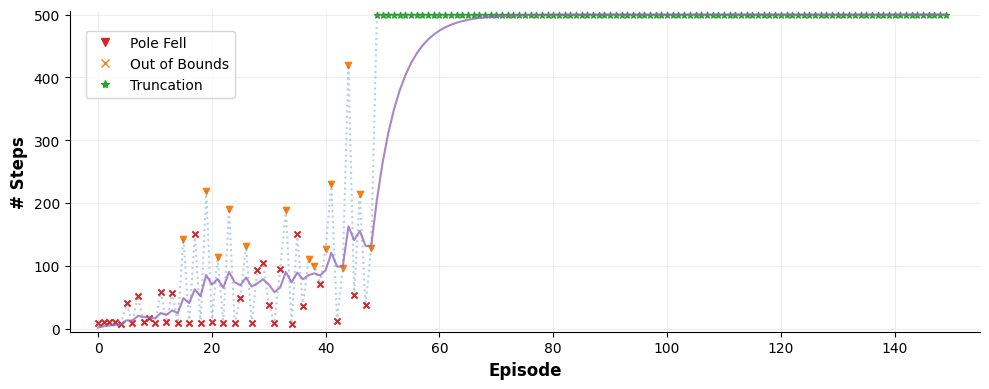

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

# Process data
s = np.arange(TRAIN_EPOCHES)
ts = np.array(train_steps)
x_oob = np.array(train_oob)
y_oob = ts[x_oob] if len(x_oob) > 0 else []
x_trnc = np.argwhere(ts == 500).reshape(-1)
y_trnc = 500*np.ones_like(x_trnc)
x_pole = [x for x in range(TRAIN_EPOCHES) if (x not in x_oob and x not in x_trnc)]
y_pole = ts[x_pole]

fig = plt.figure(figsize=(10,4))
# General curve
plt.plot(s, train_steps, alpha=1/3, linestyle=':')
plt.plot(s, train_steps_ema, color='tab:purple', alpha=0.8)
# Pole-fell
plt.scatter(x_pole, y_pole, color='tab:red', s=20, alpha=1, marker='x')
# Agent out-of-bounds
plt.scatter(x_oob, y_oob, color='tab:orange', s=20, alpha=1, marker='v')
# Episode truncated
plt.scatter(x_trnc, y_trnc, color='tab:green', s=20, alpha=1, marker='*')

# Format plot
plt.xlim(-5, TRAIN_EPOCHES+5)
plt.ylim(-5, 505)
plt.xlabel('Episode', fontweight='bold', fontsize=12)
plt.ylabel('# Steps', fontweight='bold', fontsize=12)
plt.grid(alpha=0.2)
plt.tight_layout()

legend_elements = [
	Line2D([], [], color='tab:red', marker='v', linewidth=0, label='Pole Fell'), 
	Line2D([], [], color='tab:orange', marker='x', linewidth=0, label='Out of Bounds'), 
	Line2D([], [], color='tab:green', marker='*', linewidth=0, label='Truncation'), 
]
fig.legend(handles=legend_elements, ncols=1, bbox_to_anchor=(0.165, 0.825), loc='center', frameon=True)
plt.show()

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

🎉 Congratulations! (again) 🎉 

Now you have trained your first SNN that actually does something midly interesting!

</div>